<a href="https://colab.research.google.com/github/nguyenhoangan7941/Homework/blob/main/Homework1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
#Cau1
import folium
m=folium.Map(location=[10.76130,106.66841],zoom_start=13)
folium.Marker(
    [10.76130,106.66841],
    popup="UEH Nguyen Tri Phuong",
    icon=folium.Icon(color='red'),
    tooltip="Click vao").add_to(m)
locations={
    'Van Hanh Mall':[10.77088, 106.66997],
    'Benh Vien Nhi Dong 1':[10.76936, 106.67099],
    "Cong An Quan 10":[10.77254, 106.66493],
    "Ben Xe Nhat Tao":[10.76367, 106.66214],
    "Ways Station Gym":[10.77856, 106.66354]
}
for name, coordinates in locations.items():
  folium.Marker(location=coordinates,popup=name,tooltip='Click vao', icon=folium.Icon(color='lightgreen')).add_to(m)
folium.LayerControl().add_to(m)
m


In [9]:
#Cau2
from geopy.geocoders import Nominatim
from geopy.distance import geodesic
import folium
import time
geolocator = Nominatim(user_agent="colab-map-demo", timeout=10)

addresses = [
    "11 Sư Vạn Hạnh, Quận 10, TP.HCM, Vietnam",
    "54 Thành Thái, Quận 10, TP.HCM, Vietnam",
    "XX1 Đồng Nai, Quận 10, TP.HCM, Vietnam",
    "54 Nguyễn Văn Thủ, Quận 1, TP.HCM, Vietnam",
    "1A Hoàng Diệu, Phú Nhuận, TP.HCM, Vietnam"
]

locations = []

for addr in addresses:
    location = geolocator.geocode(addr)

    if location:
        coord = (location.latitude, location.longitude)
        locations.append((addr, coord))
        print(f"{addr}: {coord}")
    else:
        print(f"Không tìm thấy: {addr}")

center = [10.78368, 106.65996]

m = folium.Map(location=center, zoom_start=13)

folium.Marker(
    center,
    popup="Trung tâm",
    icon=folium.Icon(color='red')
).add_to(m)

for addr, coord in locations:
    distance = geodesic(center, coord).km

    folium.Marker(
        location=coord,
        popup=f"{addr}<br>{distance:.2f} km",
        icon=folium.Icon(color="blue")
    ).add_to(m)

    folium.PolyLine(
        locations=[center, coord],
        color="green",
        weight=2
    ).add_to(m)
m



11 Sư Vạn Hạnh, Quận 10, TP.HCM, Vietnam: (10.7704843, 106.6695631)
54 Thành Thái, Quận 10, TP.HCM, Vietnam: (10.7705604, 106.6998676)
XX1 Đồng Nai, Quận 10, TP.HCM, Vietnam: (10.7787774, 106.6618993)
54 Nguyễn Văn Thủ, Quận 1, TP.HCM, Vietnam: (10.7558966, 106.6854206)
1A Hoàng Diệu, Phú Nhuận, TP.HCM, Vietnam: (10.7961027, 106.6723053)


In [10]:
#Cau3
import folium
import random
from folium.plugins import HeatMap
center = [10.78368, 106.65996]

m = folium.Map(location=center, zoom_start=13)
heat_data = []

for _ in range(100):
    lat = center[0] + random.uniform(-0.02, 0.02)
    lon = center[1] + random.uniform(-0.02, 0.02)
    heat_data.append([lat, lon])

HeatMap(heat_data).add_to(m)
m


- Các vùng nóng (màu đỏ): Tập trung nhiều khách hàng/đơn hàng -> Doanh nghiệp nên mở rộng chi nhánh, tăng nguồn lực phục vụ, đẩy mạnh marketing
- Các vùng lạnh (màu xanh): Ít khách hàng -> Xem xét nguyên nhân (vị trí, nhu cầu thấp), tối ưu chi phí, mở chiến dịch thu hút khách

In [24]:
#Cau4
import geopandas as gpd
import matplotlib.pyplot as plt
path_to_data="/content/gadm41_VNM_1.json"
vietnam_provinces=gpd.read_file(path_to_data)
print(vietnam_provinces.head())

import random

vietnam_provinces["dan_so"] = [
    random.randint(500000, 10000000)
    for _ in range(len(vietnam_provinces))]

import folium
m= folium.Map([16,106],zoom_start=5)
folium.Choropleth(
    geo_data=vietnam_provinces,name="choropleth",
    data=vietnam_provinces,
    columns=["NAME_1","dan_so"],
    key_on="feature.properties.NAME_1",
    fill_color="YlOrRd",
    fill_opacity=0.7,
    line_opacity=0.2,
    legend_name="Dân số").add_to(m)
folium.LayerControl().add_to(m)
m




     GID_1 GID_0  COUNTRY         NAME_1      VARNAME_1 NL_NAME_1 TYPE_1  \
0  VNM.1_1   VNM  Vietnam        AnGiang        AnGiang        NA   Tỉnh   
1  VNM.7_1   VNM  Vietnam  BàRịa-VũngTàu  BaRia-VungTau        NA   Tỉnh   
2  VNM.3_1   VNM  Vietnam       BắcGiang       BacGiang        NA   Tỉnh   
3  VNM.4_1   VNM  Vietnam         BắcKạn         BacKan        NA   Tỉnh   
4  VNM.2_1   VNM  Vietnam        BạcLiêu        BacLieu        NA   Tỉnh   

  ENGTYPE_1 CC_1 HASC_1  ISO_1  \
0  Province   NA  VN.AG  VN-44   
1  Province   NA  VN.BV     NA   
2  Province   NA  VN.BG     NA   
3  Province   NA  VN.BK     NA   
4  Province   NA  VN.BL     NA   

                                            geometry  
0  MULTIPOLYGON (((105.5486 10.4295, 105.5495 10....  
1  MULTIPOLYGON (((107.0901 10.324, 107.0889 10.3...  
2  MULTIPOLYGON (((106.2838 21.1323, 106.2734 21....  
3  MULTIPOLYGON (((105.8724 21.8558, 105.8629 21....  
4  MULTIPOLYGON (((105.4244 9.0213, 105.4164 9.01...  


- Bản đồ choropleth thể hiện sự phân bố dân số giữa các tỉnh thành.
Các khu vực có màu đậm biểu thị dân số cao, tập trung ở các đô thị lớn, trong khi các khu vực màu nhạt có mật độ thấp hơn.
--> Điều này giúp nhà quản lý xác định khu vực trọng điểm để phân bổ nguồn lực và phát triển kinh tế.

In [12]:
import folium
import random
from geopy.distance import geodesic
center = [10.78368, 106.65996]

m = folium.Map(location=center, zoom_start=13)
folium.Marker(
    location=center,
    popup="Trung tâm phân phối",
    icon=folium.Icon(color='red')).add_to(m)
folium.Circle(location=center,radius=3000,color="green",fill=True,fill_opacity=0.2).add_to(m)
folium.Circle(location=center,radius=5000,color="orange",fill=True,fill_opacity=0.2).add_to(m)
folium.Circle(location=center,radius=10000,color="red",fill=True,fill_opacity=0.2).add_to(m)

customers=[]
for _ in range(40):
  lat=center[0]+random.uniform(-0.05,0.05)
  lon=center[1]+random.uniform(-0.05,0.05)
  customers.append((lat,lon))

count_3km=0
count_5km=0
count_10km=0
count_out=0
for coord in customers:
    d = geodesic(center, coord).km

    if d <= 3:
        color = "green"
        count_3km += 1
    elif d <= 5:
        color = "orange"
        count_5km += 1
    elif d <= 10:
        color = "red"
        count_10km += 1
    else:
        color = "gray"
        count_out += 1

    folium.Marker(
        location=coord,
        popup=f"{d:.2f} km",
        icon=folium.Icon(color=color)).add_to(m)
print("Khách trong 3km:", count_3km)
print("Khách trong 3-5km:", count_5km)
print("Khách trong 5-10km:", count_10km)
print("Ngoài 10km:", count_out)
m


Khách trong 3km: 9
Khách trong 3-5km: 20
Khách trong 5-10km: 11
Ngoài 10km: 0



- Phần lớn khách tập trung trong phạm vi 3-5km -> nên tập trung hoạt động vùng này để tối ưu chi phí và thời gian
- Vùng 5-10km có thể phục vụ nhưng chi phí tăng

In [13]:
!pip install folium geopy osmnx networkx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.4/104.4 kB 7.6 MB/s eta 0:00:00


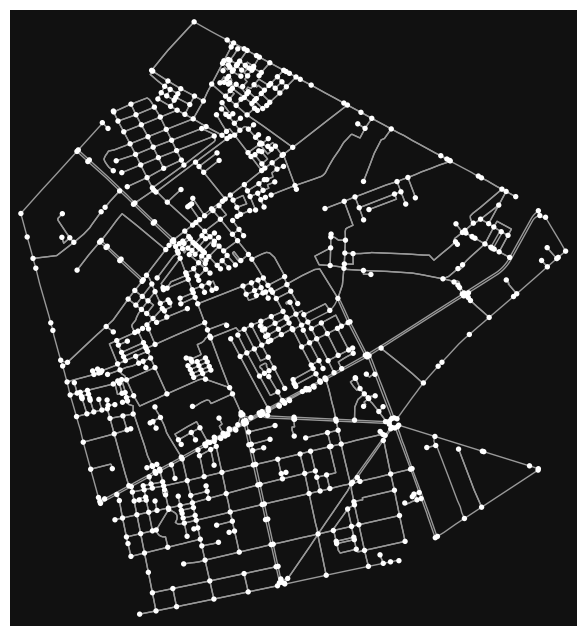

Số nút: 912
Số cạnh: 2142
Độ dài trung bình: 75.99036355864419
Mật độ: 2.348684210526316


In [14]:
#Cau6
import folium
from geopy.geocoders import Nominatim
import osmnx as ox
import networkx as nx
place="District 10, Ho Chi Minh City, Vietnam"
G=ox.graph_from_place(place,network_type='drive')
ox.plot_graph(G)

num_nodes=len(G.nodes)
num_edges=len(G.edges)
total_length = sum(data['length'] for u, v, data in G.edges(data=True))
avg_length= total_length/num_edges
density= num_edges/num_nodes

print("Số nút:", num_nodes)
print("Số cạnh:", num_edges)
print("Độ dài trung bình:", avg_length)
print("Mật độ:", density)




-Vai trò của dữ liệu mạng giao thông trong các hệ thống AI đô thị thông minh
+ Tối ưu lộ trình -> tìm đường đi ngắn nhất, nhanh nhất
+ Dự báo giao thông -> giảm ùn tắc
+ Quy hoạch đô thị -> xác định khu vực cần mở rộng
+ Hệ thống giao hàng thông minh -> tối ưu chi phí vận chuyển

In [15]:
#Cau7
import osmnx as ox
import networkx as nx
import folium
from geopy.geocoders import Nominatim
from geopy.distance import geodesic

place="District 10 , Ho Chi Minh City, Vietnam"
G=ox.graph_from_place(place,network_type='drive')

address_A = [10.762622, 106.660172]
address_B = [10.778200, 106.664800]

orig=ox.distance.nearest_nodes(G,address_A[1],address_A[0])
dest=ox.distance.nearest_nodes(G,address_B[1],address_B[0])

route_dijkstra=nx.shortest_path(G,orig,dest,weight='length')
route_astar=nx.astar_path(G,orig,dest,weight='length')
length_dijkstra = nx.shortest_path_length(G, orig, dest, weight='length')
length_astar = nx.astar_path_length(G, orig, dest, weight='length')

print("Dijkstra length:", round(length_dijkstra,2))
print("A* length:", round(length_astar,2))

m = folium.Map(location=address_A, zoom_start=14)

route1 = [(G.nodes[n]['y'], G.nodes[n]['x']) for n in route_dijkstra]
route2 = [(G.nodes[n]['y'], G.nodes[n]['x']) for n in route_astar]

folium.PolyLine(route1, color="blue", weight=5, tooltip="Dijkstra").add_to(m)

folium.PolyLine(route2, color="red", weight=3, tooltip="A*").add_to(m)

folium.Marker(address_A, popup="UEH Nguyễn Tri Phương").add_to(m)
folium.Marker(address_B, popup="Vạn Hạnh Mall").add_to(m)
m



Dijkstra length: 2230.29
A* length: 2230.29




1.   Dijkstra
 + Ưu điểm: tìm đường ngắn nhất chính xác tuyệt đối, không cần thêm thông tin gì
 + Nhược điểm: xét rất nhiều nút -> chậm khi mạng lớn
2.   A*
 + Ưu điểm: dùng heuristic (ước lượng khoảng cách) -> tìm nhanh hơn, hiệu quả với bản đồ lớn
 + Nhược điểm: cài đặt phức tạp hơn dijkstra, phụ thuộc heuristic -> nếu ước lượng kém có thể chậm hơn





In [16]:
#Cau8
import folium
import random
from geopy.distance import geodesic

center = [10.78368, 106.65996]

m = folium.Map(location=center, zoom_start=13)

drivers=[]
customers=[]
for _ in range(5):
  lat=center[0]+random.uniform(-0.02,0.02)
  lon=center[1]+random.uniform(-0.02,0.02)
  drivers.append((lat,lon))
for _ in range(5):
  lat=center[0]+random.uniform(-0.02,0.02)
  lon=center[1]+random.uniform(-0.02,0.02)
  customers.append((lat,lon))

  for d in drivers:
    folium.Marker(
        location=d,popup='Xe',
        icon=folium.Icon(color="blue",icon="car")).add_to(m)
  for c in customers:
    folium.Marker(
        location=c,popup="Khách",
        icon=folium.Icon(color="red")).add_to(m)

  for c in customers:
    min_dist = float('inf')
    best_driver = None

    for d in drivers:
        dist = geodesic(c, d).km
        if dist < min_dist:
            min_dist = dist
            best_driver = d
    folium.PolyLine(
      locations=[c, best_driver],
      color="green",
      weight=2,
      tooltip=f"{min_dist:.2f}km").add_to(m)
m





In [17]:
#Cau9
import folium
import random
import numpy as np
from sklearn.cluster import KMeans

center = [10.78368, 106.65996]

customers = []
for _ in range(100):
    lat = center[0] + random.uniform(-0.02, 0.02)
    lon = center[1] + random.uniform(-0.02, 0.02)
    customers.append([lat, lon])

customers = np.array(customers)

k = 3
kmeans = KMeans(n_clusters=k, random_state=0)
kmeans.fit(customers)

labels = kmeans.labels_
centers = kmeans.cluster_centers_

m = folium.Map(location=center, zoom_start=14)

colors = ["red", "blue", "green"]

for i, point in enumerate(customers):
    folium.CircleMarker(
        location=point,
        radius=4,
        color=colors[labels[i]],
        fill=True).add_to(m)

for i, c in enumerate(centers):
    folium.Marker(
        location=c,
        popup=f"Trạm {i+1}",
        icon=folium.Icon(color="black", icon="info-sign")).add_to(m)

m

In [18]:
#Cau10
import folium
import random

center = [10.78368, 106.65996]

m = folium.Map(location=center, zoom_start=14)

points = []

for _ in range(50):
    lat = center[0] + random.uniform(-0.02, 0.02)
    lon = center[1] + random.uniform(-0.02, 0.02)

    density = random.randint(1, 100)
    speed = random.randint(10, 60)

    risk_score = density / speed

    if risk_score > 5:
        level = "High"
        color = "red"
    elif risk_score > 2:
        level = "Medium"
        color = "orange"
    else:
        level = "Low"
        color = "green"

    points.append((lat, lon, level, risk_score))

    folium.CircleMarker(
        location=[lat, lon],
        radius=6,
        color=color,
        fill=True,
        popup=f"{level} ({risk_score:.2f})"
    ).add_to(m)

route = [
    [10.770, 106.650],
    [10.775, 106.655],
    [10.780, 106.660],
    [10.785, 106.665]]

folium.PolyLine(
    route,
    color="blue",
    weight=3,
    tooltip="Tuyến đề xuất").add_to(m)

m

In [19]:
#Cau11
import folium
import random
import pandas as pd
from sklearn.linear_model import LinearRegression

center = [10.78368, 106.65996]

data = []

for _ in range(50):
    lat = center[0] + random.uniform(-0.02, 0.02)
    lon = center[1] + random.uniform(-0.02, 0.02)

    time = random.randint(0, 23)  # giờ
    demand = random.randint(10, 100)  # nhu cầu

    data.append([lat, lon, time, demand])

df = pd.DataFrame(data, columns=["lat", "lon", "time", "demand"])

X = df[["time"]]
y = df["demand"]

model = LinearRegression()
model.fit(X, y)

df["predicted"] = model.predict(df[["time"]])

m = folium.Map(location=center, zoom_start=14)
for _, row in df.iterrows():
    if row["predicted"] > 70:
        color = "red"
    elif row["predicted"] > 40:
        color = "orange"
    else:
        color = "green"

    folium.CircleMarker(
        location=[row["lat"], row["lon"]],
        radius=5,
        color=color,
        fill=True,
        popup=f"Nhu cầu: {row['predicted']:.1f}"
    ).add_to(m)

m



1.   Khu vực đỏ: mật độ khách hàng, nhu cầu lớn, đặc biệt vài giờ cao điểm
2.   Khu vực cam: nhu cầu ở mức trung bình, biến động theo thời gian
3. Khu vực xanh: nhu cầu thấp, ít phát sinh đơn hàng
4. Ý nghĩa trong điều phối nguồn nhân lực:
- Phân bổ xe/nhân lực theo nhu cầu: tăng xe ở khu vực nhu cầu cao, giảm ở khu vực nhu cầu thấp
- Lập kế hoạch theo thời gian: tăng nguồn lực vào giờ cao điểm, giảm vào giờ thấp điểm
- Giảm chi phí vận hành: tránh dư thừa xe, tối ưu quãng đường di chuyển





In [20]:
#Cau12
import folium
import random
from geopy.distance import geodesic

warehouses = [
    [10.78368, 106.65996],
    [10.77000, 106.67000],
    [10.77500, 106.65000]]

customers = []
for _ in range(12):
    lat = 10.78 + random.uniform(-0.02, 0.02)
    lon = 106.66 + random.uniform(-0.02, 0.02)
    customers.append([lat, lon])

m = folium.Map(location=warehouses[0], zoom_start=14)

for i, w in enumerate(warehouses):
    folium.Marker(
        w,
        popup=f"Kho {i+1}",
        icon=folium.Icon(color="red")
    ).add_to(m)

clusters = {0: [], 1: [], 2: []}

for c in customers:
    distances = [geodesic(c, w).km for w in warehouses]
    nearest_index = distances.index(min(distances))
    clusters[nearest_index].append(c)

    folium.Marker(c, popup="Khách", icon=folium.Icon(color="blue")).add_to(m)
colors = ["green", "purple", "orange"]

for i in clusters:
    remaining = clusters[i].copy()
    current = warehouses[i]
    route = [current]

    while remaining:
        nearest = min(remaining, key=lambda x: geodesic(current, x).km)
        route.append(nearest)
        remaining.remove(nearest)
        current = nearest

    route.append(warehouses[i])

    for j in range(len(route)-1):
        folium.PolyLine(
            [route[j], route[j+1]],
            color=colors[i],
            weight=4,
            tooltip=f"Kho {i+1}"
        ).add_to(m)

m

So với phương án không tối ưu (đi theo thứ tự ngẫu nhiên), phương án tối ưu cho thấy sự cải thiện rõ rệt về quãng đường và hiệu quả vận hành.

1. Tuyến không tối ưu:
- Di chuyển không hợp lý, có nhiều đoạn vòng lại
- Tổng quãng đường dài hơn
- Tốn thời gian và chi phí vận chuyển
2. Tuyến tối ưu:
- Các điểm được sắp xếp theo khoảng cách gần nhất
- Giảm đáng kể quãng đường di chuyển
- Hạn chế di chuyển dư thừa
- Tăng số đơn hàng xử lý trong cùng thời gian

In [21]:
#Cau13
import folium
import random

center = [10.78368, 106.65996]

m = folium.Map(location=center, zoom_start=13)

customer_layer = folium.FeatureGroup(name="Khách hàng")

customers = []
for _ in range(20):
    lat = center[0] + random.uniform(-0.02, 0.02)
    lon = center[1] + random.uniform(-0.02, 0.02)
    customers.append([lat, lon])

    folium.Marker(
        [lat, lon],
        popup="Khách",
        icon=folium.Icon(color="blue")
    ).add_to(customer_layer)

customer_layer.add_to(m)

area_layer = folium.FeatureGroup(name="Vùng phục vụ")

folium.Circle(center, radius=3000, color="green", fill=True, fill_opacity=0.1).add_to(area_layer)
folium.Circle(center, radius=6000, color="orange", fill=True, fill_opacity=0.1).add_to(area_layer)

area_layer.add_to(m)

route_layer = folium.FeatureGroup(name="Tuyến đường")

route = [
    [10.770, 106.650],
    [10.775, 106.655],
    [10.780, 106.660],
    [10.785, 106.665]
]

folium.PolyLine(route, color="red", weight=4, tooltip="Tuyến chính").add_to(route_layer)

route_layer.add_to(m)

folium.LayerControl().add_to(m)

m

In [22]:
#Cau14
import folium
import random
import time

center = [10.78368, 106.65996]

m = folium.Map(location=center, zoom_start=14)

vehicles = [
    [10.78, 106.66],
    [10.77, 106.67],
    [10.79, 106.65]]

targets = [
    [10.775, 106.665],
    [10.782, 106.670],
    [10.785, 106.655]]

def move_step(current, target, step=0.001):
    lat = current[0]
    lon = current[1]

    if abs(target[0] - lat) > step:
        lat += step if target[0] > lat else -step

    if abs(target[1] - lon) > step:
        lon += step if target[1] > lon else -step

    return [lat, lon]

for t in range(20):

    layer = folium.FeatureGroup(name=f"Time {t}")

    for i in range(len(vehicles)):
        vehicles[i] = move_step(vehicles[i], targets[i])

        folium.Marker(
            vehicles[i],
            popup=f"Xe {i+1} - t={t}",
            icon=folium.Icon(color="blue", icon="car")
        ).add_to(layer)

        folium.Marker(
            targets[i],
            popup=f"Khách {i+1}",
            icon=folium.Icon(color="red")
        ).add_to(layer)

    layer.add_to(m)

folium.LayerControl().add_to(m)

m

In [23]:
#Cau15
import folium
import random
import numpy as np
from sklearn.cluster import KMeans
from geopy.distance import geodesic
from folium.plugins import HeatMap

center = [10.78368, 106.65996]

m = folium.Map(location=center, zoom_start=14)

customers = []
for _ in range(80):
    lat = center[0] + random.uniform(-0.03, 0.03)
    lon = center[1] + random.uniform(-0.03, 0.03)
    customers.append([lat, lon])

customers = np.array(customers)

k = 3
kmeans = KMeans(n_clusters=k, random_state=0).fit(customers)
labels = kmeans.labels_
centers = kmeans.cluster_centers_

colors = ["red", "blue", "green"]

for i, point in enumerate(customers):
    folium.CircleMarker(
        location=point,
        radius=4,
        color=colors[labels[i]],
        fill=True,
        fill_opacity=0.7,
        tooltip=f"Cluster {labels[i]}"
    ).add_to(m)

for i, c in enumerate(centers):
    folium.Marker(
        location=c,
        popup=f"Trạm {i+1}",
        icon=folium.Icon(color="black")
    ).add_to(m)

for i in range(k):
    cluster_points = customers[labels == i].tolist()
    current = centers[i]
    route = [current]

    while cluster_points:
        nearest = min(cluster_points, key=lambda x: geodesic(current, x).km)
        route.append(nearest)
        cluster_points.remove(nearest)
        current = nearest

    for j in range(len(route)-1):
        folium.PolyLine(
            [route[j], route[j+1]],
            color=colors[i],
            weight=3
        ).add_to(m)

HeatMap(customers.tolist()).add_to(m)

m

1. Dữ liệu sử dụng trong bài gồm:

- Tọa độ vị trí khách hàng (latitude, longitude)
- Dữ liệu được giả lập xung quanh một khu vực trung tâm
- Các điểm dữ liệu thể hiện phân bố nhu cầu trong không gian
2. Phương pháp AI

Bài toán sử dụng hai phương pháp chính:

- K-Means Clustering
→ phân cụm khách hàng thành các nhóm có vị trí gần nhau
- Nearest Neighbor (heuristic)
→ xây dựng tuyến giao hàng tối ưu bằng cách luôn chọn điểm gần nhất

Ngoài ra, heatmap được sử dụng để trực quan hóa mật độ nhu cầu.

3. Trực quan hóa

Bản đồ thể hiện:

- Các điểm khách hàng theo cụm màu
- Vị trí trạm đề xuất (tâm cụm)
- Tuyến giao hàng tối ưu
- Heatmap thể hiện mật độ nhu cầu
4. Giá trị ứng dụng thực tiễn

- Xác định khu vực có nhu cầu cao
- Tối ưu vị trí đặt kho hoặc trạm trung chuyển
- Giảm chi phí vận chuyển và thời gian giao hàng
- Hỗ trợ doanh nghiệp ra quyết định nhanh chóng